### Supplemental Figure 1

In [22]:
from collections import *
import matplotlib.pyplot as plt, mpld3
from matplotlib import gridspec  
import pandas as pd
import numpy as np
import seaborn as sns
from io import StringIO
import os

os.chdir("~/3.SV/PCA/")  

In [31]:
df_ped_str ="""
ArH-F10 ArH
ArH-F11 ArH
ArH-F13 ArH
ArH-F14 ArH
ArH-F1 ArH
ArH-F23 ArH
ARH-F24 ArH
ArH-F25 ARH
ARH-F2 ArH
ArH-F9 ArH
ArH-M12 ArH
ARH-M16 ArH
ArH-M19 ArH
ARH-M1 ArH
ArH-M21 ArH
ArH-M24 ArH
ArH-M2 ArH
ArH-M5 ArH
ArH-M7 ArH
ArH-M9 ArH
ArL-F10 ArL
ArL-F15 ArL
ArL-F16 ArL
ArL-F18 ArL
ArL-F19 ArL
ArL-F20 ArL
ArL-F22 ArL
ArL-F5 ArL
ArL-F8 ArL
ArL-F9 ArL
ArL-M11 ArL
ArL-M12 ArL
ARL-M15 ArL
ArL-M16 ArL
ARL-M17 ArL
ArL-M19 ArL
ArL-M1 ArL
ArL-M24 ArL
ARL-M25 ArL
ArL-M6 ArL
QuH-F12 QuH
QuH-F13 QuH
QuH-F21 QuH
QuH-F22 QuH
QuH-F25 QuH
QuH-F3 QuH
QuH-F4 QuH
QuH-F6 QuH
QuH-F7 QuH
QuH-F9 QuH
QuH-M10 QuH
QuH-M13 QuH
QuH-M17 QuH
QuH-M19 QuH
QuH-M22 QuH
QuH-M2 QuH
QuH-M3 QuH
QUH-M4 QuH
QUH-M9 QuH
QuL-F11 QuL
QuL-F14 QuL
QuL-F15 QuL
QUL-F16 QuL
QuL-F19 QuL
QuL-F23 QuL
QuL-F4 QuL
QUL-F5 QuL
QuL-F6 QuL
QuL-F7 QuL
QuL-M11 QuL
QuL-M15 QuL
QuL-M17 QuL
QuL-M20 QuL
QuL-M25 QuL
QuL-M2 QuL
QUL-M4 QuL
QuL-M5 QuL
QuL-M6 QuL
QuL-M8 QuL
YAH-F12 YaH
YaH-F13 YaH
YaH-F14 YaH
YaH-F15 YaH
YaH-F18 YaH
YaH-F19 YaH
YaH-F1 YaH
YaH-F21 YaH
YaH-F24 YaH
YaH-F9 YaH
YaH-M10 YaH
YaH-M11 YaH
YaH-M16 YaH
YaH-M17 YaH
YaH-M18 YaH
YaH-M21 YaH
YaH-M23 YaH
YaH-M2 YaH
YaH-M5 YaH
YaH-M6 YaH
YaL-F10 YaL
YaL-F11 YaL
YaL-F12 YaL
YaL-F13 YaL
YaL-F19 YaL
YAL-F20 YaL
YaL-F22 YaL
YaL-F24 YaL
YaL-F4 YaL
YaL-F6 YaL
YAL-M10 YaL
YaL-M11 YaL
YaL-M14 YaL
YaL-M16 YaL
YaL-M17 YaL
YaL-M18 YaL
YaL-M21 YaL
YaL-M23 YaL
YaL-M25 YaL
YaL-M7 YaL
YAL-M8 YaL
"""

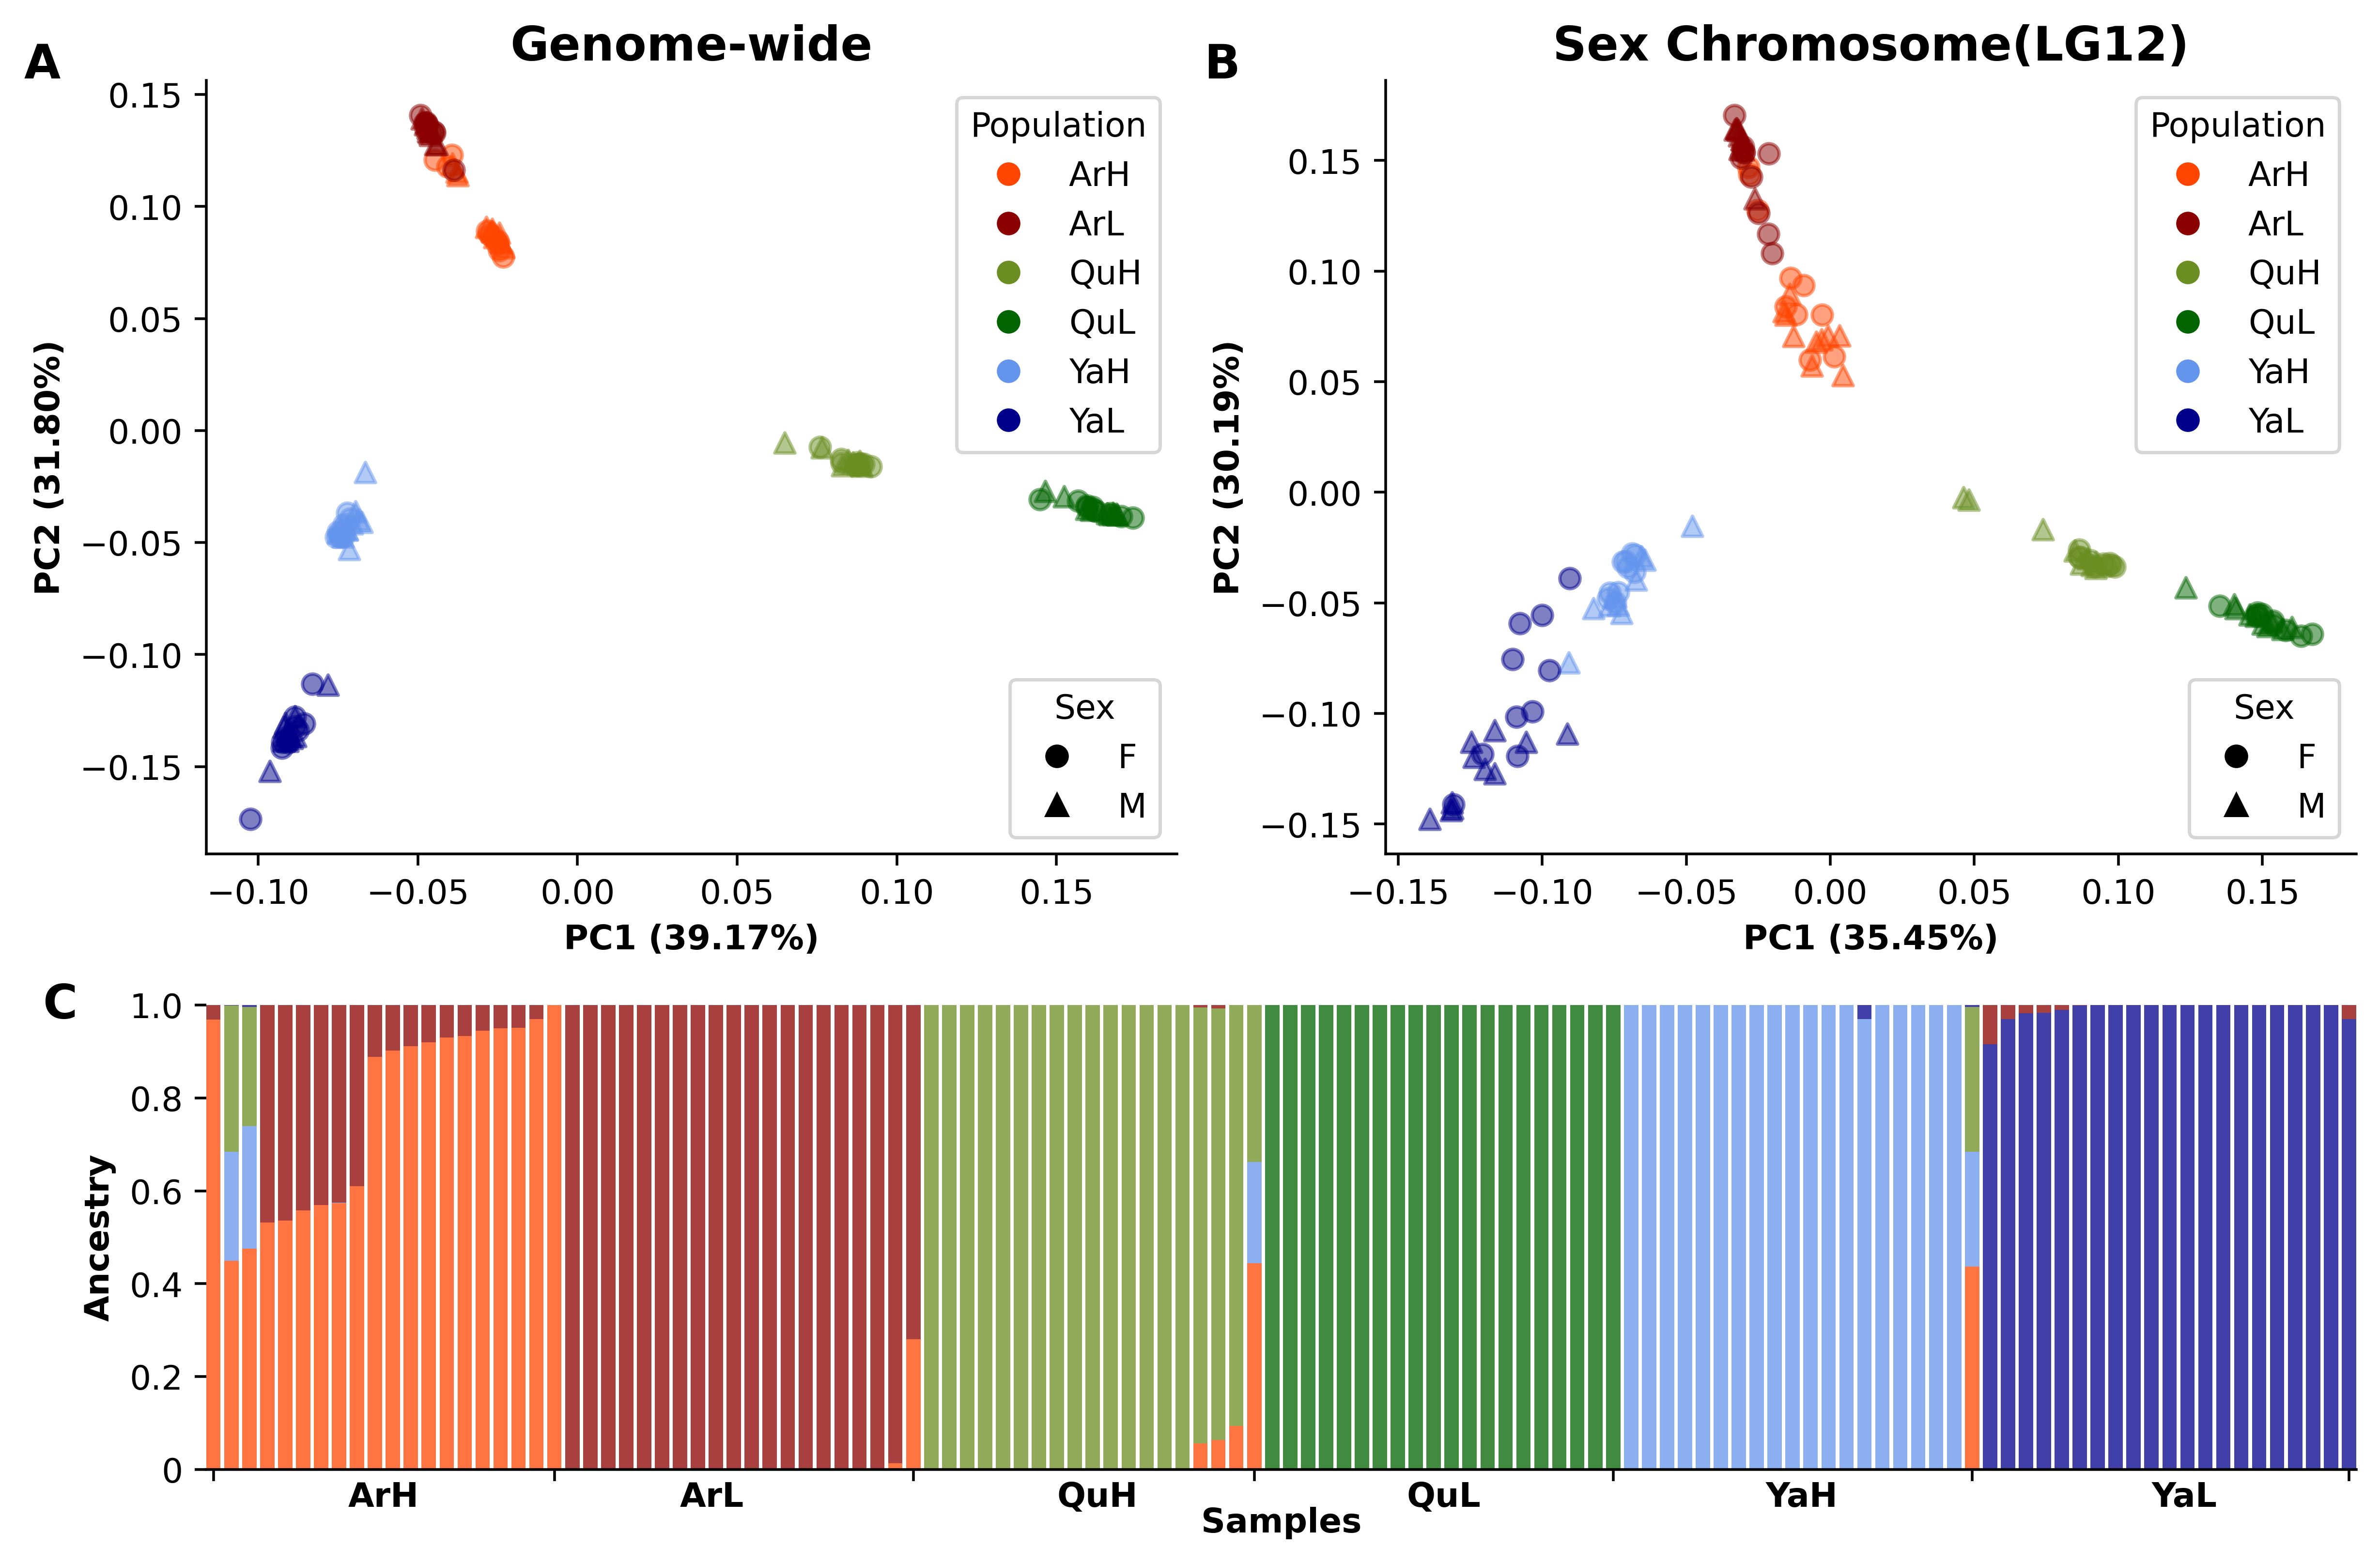

In [33]:
# Function to load data and extract population and sex
def findPop(data='data.pca.eigenvec'):
    sex = []
    pop = []
    df = pd.read_csv(data, sep='\t', header=0)
    for i in list(df['IID']):
        i = i.upper()
        sex.append(i[4])  
        s = i[:3]
        s = s[0].upper() + s[1].lower() + s[2].upper()
        pop.append(s)
    df['POPULATION'] = pop
    df['SEX'] = sex
    return df

# Load datasets
data = findPop()
data2 = findPop('LG12.eigenvec')

# Define color schemes and marker shapes
colors = {
    'ArH': 'orangered', 'ArL': 'darkred',
    'QuH': 'olivedrab', 'QuL': 'darkgreen',
    'YaH': 'cornflowerblue', 'YaL': 'darkblue'
}
sex_markers = {"F": "o", "M": "^"}

# Create a figure and GridSpec layout with 2 rows and 2 columns
fig = plt.figure(figsize=(10, 6.5), dpi=500)
gs = gridspec.GridSpec(2, 2, height_ratios=[2, 1.2])  # 2 rows, 2 columns

# Create three subplots from the GridSpec
ax1 = fig.add_subplot(gs[0, 0])  # First subplot (row 0, column 0)
ax2 = fig.add_subplot(gs[0, 1])  # Second subplot (row 0, column 1)
ax3 = fig.add_subplot(gs[1, :])   # Third subplot spanning both columns in the second row

# Plotting data for ax1
for pop in colors.keys():
    for s in sex_markers.keys():
        subset = data[(data['POPULATION'] == pop) & (data['SEX'] == s)]
        ax1.scatter(subset['PC1'], subset['PC2'], color=colors[pop], marker=sex_markers[s], alpha=0.5, label=f'{pop}, {s}')

# Plotting data for ax2
for pop in colors.keys():
    for s in sex_markers.keys():
        subset = data2[(data2['POPULATION'] == pop) & (data2['SEX'] == s)]
        ax2.scatter(subset['PC1'], subset['PC2'], color=colors[pop], marker=sex_markers[s], alpha=0.5)

# Customize subplots
for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Set axis labels
ax1.set_xlabel('PC1 (39.17%)', fontweight='bold')
ax1.set_ylabel('PC2 (31.80%)', fontweight='bold')
ax2.set_xlabel('PC1 (35.45%)', fontweight='bold')
ax2.set_ylabel('PC2 (30.19%)', fontweight='bold')

# Set titles for subplots
ax1.set_title('Genome-wide', fontweight='bold', fontsize=14)
ax2.set_title('Sex Chromosome(LG12)', fontweight='bold', fontsize=14)

# Set subplot labels
ax1.text(-0.15, 1.05, 'A', transform=ax1.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax2.text(-0.15, 1.05, 'B', transform=ax2.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')

# Create population legend for ax1
handles_pop, labels_pop = [], []
for pop, color in colors.items():
    handles_pop.append(plt.Line2D([], [], color=color, marker='o', linestyle='None'))
    labels_pop.append(pop)
pop_legend = ax1.legend(handles_pop, labels_pop, title='Population', loc='upper right')
ax1.add_artist(pop_legend)  # Add the first legend manually

# Create sex legend for ax1
handles_sex, labels_sex = [], []
for s, marker in sex_markers.items():
    handles_sex.append(plt.Line2D([], [], color='black', marker=marker, linestyle='None'))
    labels_sex.append(s)
sex_legend = ax1.legend(handles_sex, labels_sex, title='Sex', loc='lower right')

# Create population legend for ax2
pop_legend_ax2 = ax2.legend(handles_pop, labels_pop, title='Population', loc='upper right')
ax2.add_artist(pop_legend_ax2)  

# Create sex legend for ax2
sex_legend_ax2 = ax2.legend(handles_sex, labels_sex, title='Sex', loc='lower right')

# Adjust layout to avoid overlap
fig.tight_layout()

# Generate stacked bar plot in ax3
fileq = '../PCA/admixture/all.6.Q'
df_q = pd.read_csv(fileq, sep=' ', header=None)

# Assuming df_ped_str is defined earlier in your code
df_ped = pd.read_csv(StringIO(df_ped_str), sep=' ', header=None, names=['Individual_ID', 'Family_ID'])
df_q["assignment"] = df_ped["Family_ID"]

# Automatically generate column names based on number of columns in Q (pop1, pop2, pop3, etc.)
names = ["pop{}".format(i) for i in range(1, df_q.shape[1])] + ["assignment"]
df_q.columns = names

# Insert the sample names into the first column position
df_q.insert(0, 'Sample', df_ped["Individual_ID"])
df_q.set_index('Sample', inplace=True)

# Filter samples to exclude
samples_to_exclude =[]
condition = ~df_q.index.isin(samples_to_exclude)
df_q_filtered = df_q[condition]

# Sort values based on specified columns
df_q_sorted = df_q_filtered.sort_values(['assignment', 'pop1', 'pop2', 'pop3', 'pop4', 'pop5', 'pop6'], ascending=True)

# Define custom colors for each population
custom_colors = ['orangered', 'cornflowerblue', 'darkgreen', 'olivedrab', 'darkblue', 'darkred']

# Stacked bar plot with custom colors
bottom = np.zeros(len(df_q_sorted))  
for i, col in enumerate(df_q_sorted.columns[:6]):
    ax3.bar(range(len(df_q_sorted)), df_q_sorted[col], bottom=bottom, label=col, alpha=0.75, color=custom_colors[i])
    bottom += df_q_sorted[col]

# Customize ax3 appearance
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.spines['left'].set_visible(False)

# Set x-axis ticks and hide tick labels for specific positions
ax3.set_xticks([0, 19, 39, 58, 78, 98, 119])
ax3.set_xticklabels([""] * 7, rotation=45, ha='right')
ax3.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1.0])
ax3.set_yticklabels(['0', '0.2', '0.4', '0.6', '0.8', '1.0'])

# Hide the legend
ax3.legend().set_visible(False)

# Set plot margins and limits
ax3.set_xmargin(0)
ax3.set_ylim(0, 1)

# Set axis labels
ax3.set_ylabel("Ancestry", weight="bold")
ax3.set_xlabel("Samples", weight="bold")

# Set title for ax3
ax3.text(-0.06, 1.05, 'C', transform=ax3.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
ax3.text(7.5, -0.08, "ArH", fontsize=10,fontweight='bold')
ax3.text(26, -0.08, "ArL", fontsize=10,fontweight='bold')
ax3.text(47, -0.08, "QuH", fontsize=10,fontweight='bold')
ax3.text(66.5, -0.08, "QuL", fontsize=10,fontweight='bold')
ax3.text(86.5, -0.08, "YaH", fontsize=10,fontweight='bold')
ax3.text(108, -0.08, "YaL", fontsize=10,fontweight='bold')

# Show the plots
plt.savefig("S1.png", format="png", dpi = 200)
plt.savefig("S1.pdf", format="pdf", dpi = 200)
plt.show()
